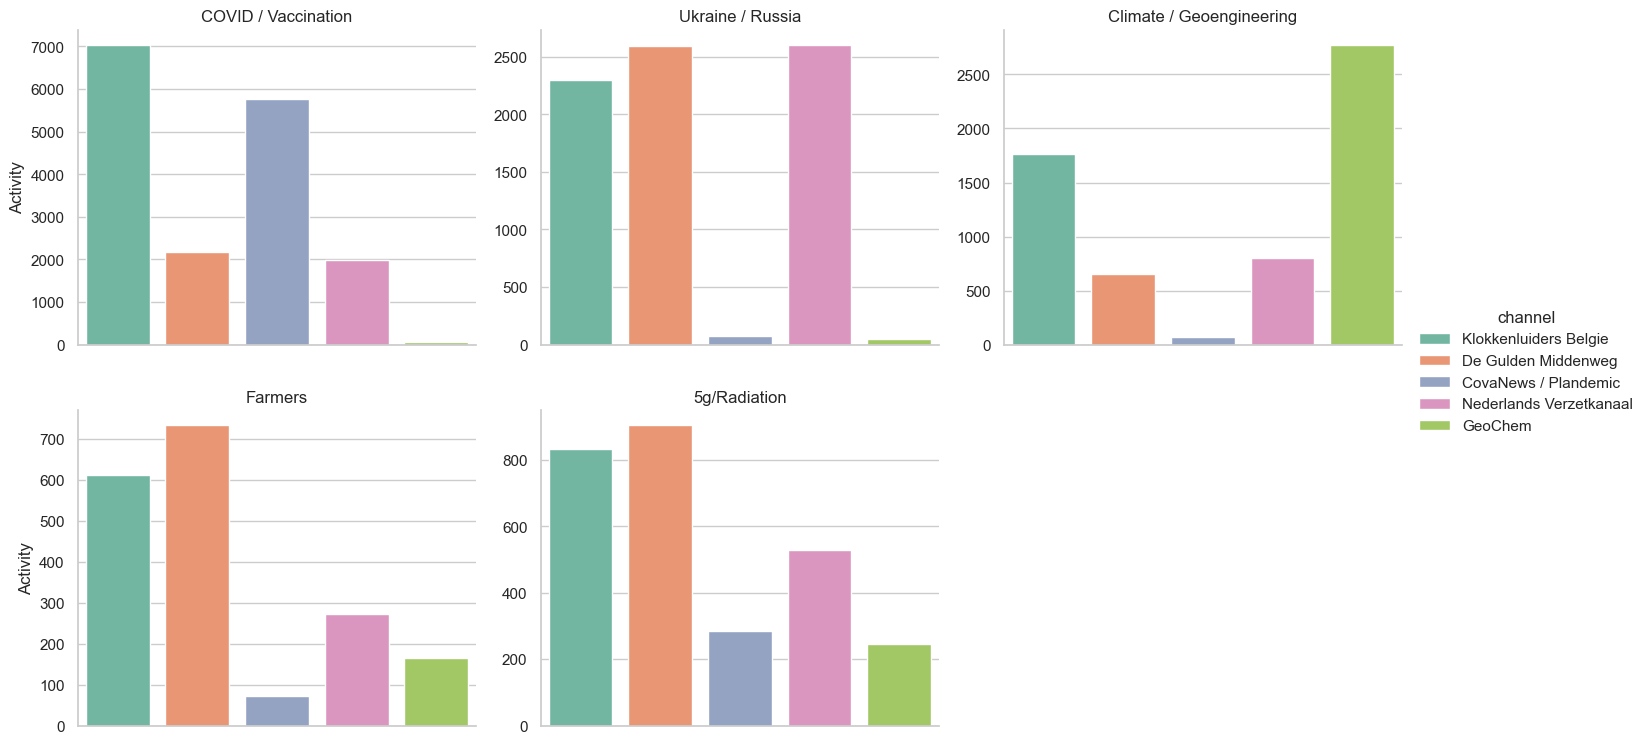

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("Data.xlsx")
df.columns = ["topic_id", "topic_label", "channel", "value"]

df["topic_label"] = df["topic_label"].astype(str)
df["channel"] = df["channel"].astype(str)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])

topic_order = df["topic_label"].drop_duplicates().tolist()
channel_order = (
    df.groupby("channel", sort=False)["value"]
      .sum()
      .sort_values(ascending=False)
      .index
      .tolist()
)

sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df,
    kind="bar",
    x="channel",
    y="value",
    hue="channel",          
    col="topic_label",
    col_wrap=3,
    order=channel_order,
    hue_order=channel_order,
    col_order=topic_order,
    sharey=False,
    height=4,
    aspect=1.2,
    palette="Set2",
    legend=True
)

g.set_axis_labels("", "Activity")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)


plt.show()